# Baseline vs Cluster Models — Валидация подхода

In [42]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import hdbscan
from config import DATASETS_DIR
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_absolute_error,
                             silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.model_selection import GroupKFold
from sklearn.decomposition import PCA
import warnings, time
warnings.filterwarnings('ignore')

%matplotlib inline

In [43]:
df = pd.read_csv(DATASETS_DIR / 'cleaned_dataset.csv', index_col=0)
print(f'Shape: {df.shape}')
print(f'Wells: {df["well_id"].nunique()}')
df.head()

Shape: (423124, 8)
Wells: 1714


,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed,source,log_EI
0,2025-10-07 22:18:14.495,104.892,12781,13144,25512,0.020200,df1,11.940683
1,2025-10-07 22:18:19.239,101.430,18971,18936,25512,0.036360,df1,12.000921
2,2025-10-07 22:18:24.208,101.430,20153,18184,25512,0.030300,df1,12.088753
3,2025-10-07 22:18:29.385,102.714,20162,17445,25512,0.030300,df1,12.076391
4,2025-10-07 22:19:13.001,103.902,18048,17389,25512,0.018937,df1,12.236005


## 1. Baseline модель (без кластеризации)

Обучаем два регрессора на `pressure_axis` и `pressure_rotation`, один предсказывает `speed`, другой `rotation`

In [44]:
FEATURES = ["pressure_axis", "pressure_rotation"]
TARGET_SPEED = "speed"
TARGET_ROT = "rotation"
GROUP_COL = "well_id"
CLUSTER_FEATURES = ["pressure_axis", "pressure_rotation", "rotation", "speed"]
K_RANGE = range(3, 14)

LGB_PARAMS = dict(n_estimators=500, learning_rate=0.05, num_leaves=31,
                  random_state=42, n_jobs=-1, verbose=-1)

X = df[FEATURES]
y_speed = df[TARGET_SPEED]
y_rot = df[TARGET_ROT]
groups = df[GROUP_COL]

gkf = GroupKFold(n_splits=5)

oof_speed = np.zeros(len(df))
oof_rot = np.zeros(len(df))

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_speed, groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    
    m_sp = lgb.LGBMRegressor(**LGB_PARAMS)
    m_rt = lgb.LGBMRegressor(**LGB_PARAMS)
    
    m_sp.fit(X_train, y_speed.iloc[train_idx])
    m_rt.fit(X_train, y_rot.iloc[train_idx])
    
    oof_speed[val_idx] = m_sp.predict(X_val)
    oof_rot[val_idx] = m_rt.predict(X_val)

baseline_r2_speed = r2_score(y_speed, oof_speed)
baseline_r2_rot = r2_score(y_rot, oof_rot)
baseline_mae_speed = mean_absolute_error(y_speed, oof_speed)
baseline_mae_rot = mean_absolute_error(y_rot, oof_rot)

print(f"Speed    R²: {baseline_r2_speed:.4f} | MAE: {baseline_mae_speed:.4f}")
print(f"Rotation R²: {baseline_r2_rot:.4f} | MAE: {baseline_mae_rot:.4f}")

Speed    R²: 0.1294 | MAE: 0.0053
Rotation R²: 0.0800 | MAE: 7.5656


## 2. Подбор числа кластеров: KMeans vs GMM (k = 3..9)

In [45]:
# Scale cluster features once
scaler = StandardScaler()
X_clust = scaler.fit_transform(df[CLUSTER_FEATURES])

# --- collect metrics ---
results = []

for k in K_RANGE:
    # KMeans
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_clust)
    km_time = time.time() - t0

    results.append(dict(
        method="KMeans", k=k,
        silhouette=silhouette_score(X_clust, km_labels, sample_size=20_000, random_state=42),
        davies_bouldin=davies_bouldin_score(X_clust, km_labels),
        calinski_harabasz=calinski_harabasz_score(X_clust, km_labels),
        inertia=km.inertia_,
        bic=None,
        fit_time=km_time,
    ))

    # GMM
    t0 = time.time()
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(X_clust)
    gmm_labels = gmm.predict(X_clust)
    gmm_time = time.time() - t0

    results.append(dict(
        method="GMM", k=k,
        silhouette=silhouette_score(X_clust, gmm_labels, sample_size=20_000, random_state=42),
        davies_bouldin=davies_bouldin_score(X_clust, gmm_labels),
        calinski_harabasz=calinski_harabasz_score(X_clust, gmm_labels),
        inertia=None,
        bic=gmm.bic(X_clust),
        fit_time=gmm_time,
    ))
    print(f"k={k}  KMeans {km_time:.1f}s  GMM {gmm_time:.1f}s")

metrics_df = pd.DataFrame(results)
print(metrics_df.to_string(index=False))

k=3  KMeans 0.7s  GMM 3.9s
k=4  KMeans 1.0s  GMM 3.4s
k=5  KMeans 1.3s  GMM 6.7s
k=6  KMeans 1.6s  GMM 4.7s
k=7  KMeans 1.6s  GMM 11.8s
k=8  KMeans 2.0s  GMM 8.9s
k=9  KMeans 1.9s  GMM 9.0s
k=10  KMeans 2.5s  GMM 9.8s
k=11  KMeans 2.2s  GMM 22.7s
k=12  KMeans 2.3s  GMM 29.4s
k=13  KMeans 2.3s  GMM 29.9s
method  k  silhouette  davies_bouldin  calinski_harabasz       inertia          bic  fit_time
KMeans  3    0.436128        0.989099      183093.430175 907289.581667          NaN  0.683848
   GMM  3    0.320021        2.050290       55038.737696           NaN 3.084610e+06  3.904287
KMeans  4    0.304346        1.064437      173215.828116 759609.242487          NaN  0.977022
   GMM  4    0.298140        2.116075       77875.692241           NaN 3.036079e+06  3.419947
KMeans  5    0.291562        1.034652      172629.188787 643054.430075          NaN  1.277869
   GMM  5    0.332067        1.637387      105651.371661           NaN 2.702170e+06  6.710719
KMeans  6    0.304601        1.050644

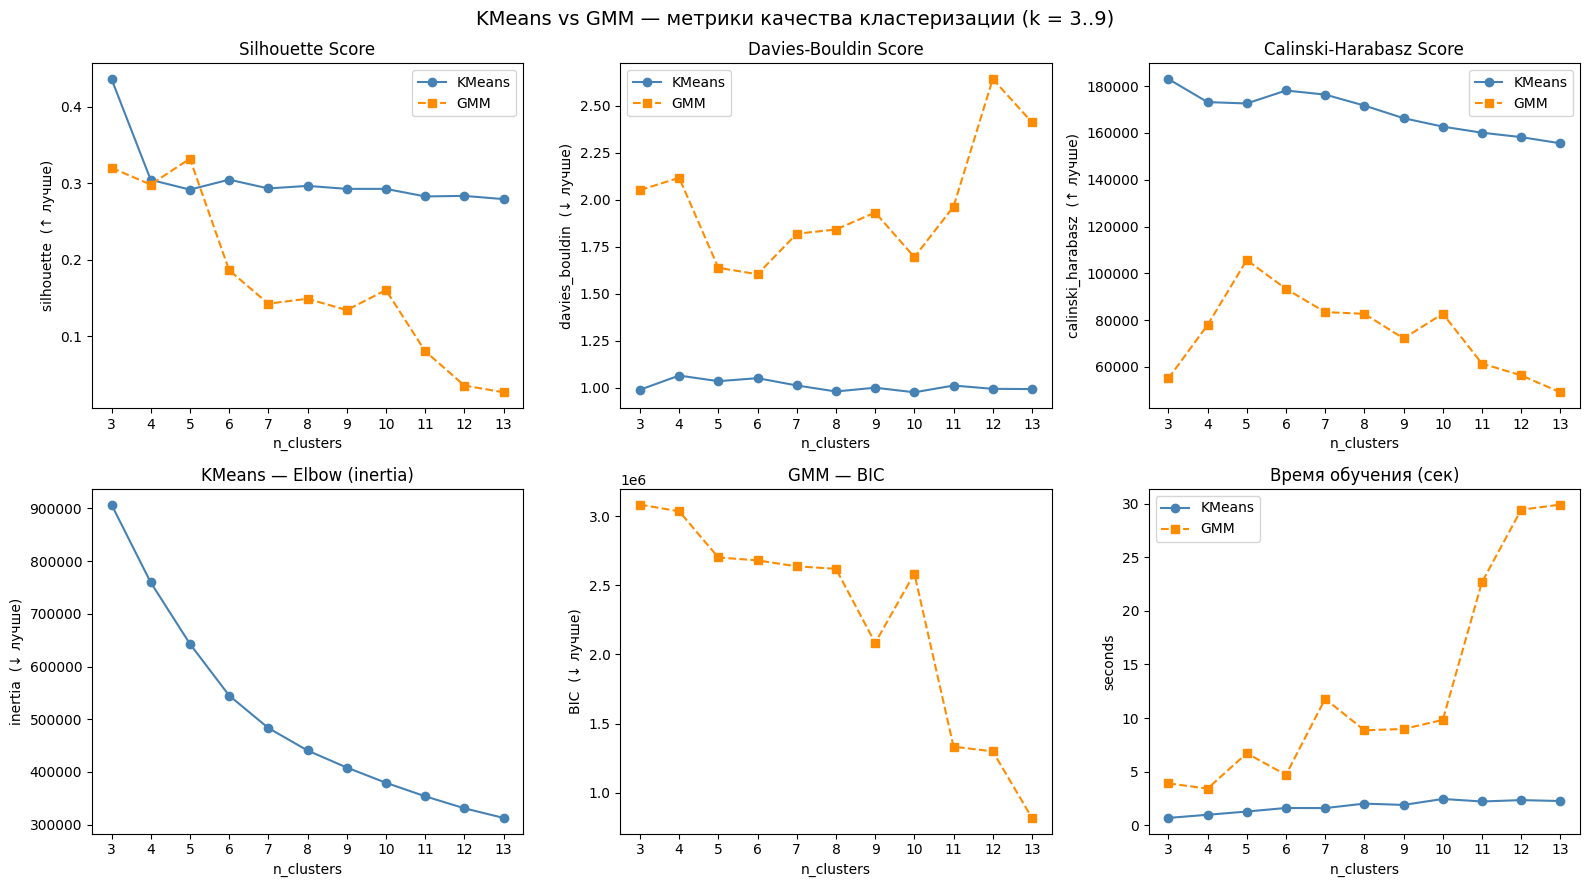

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("KMeans vs GMM — метрики качества кластеризации (k = 3..9)", fontsize=14)

km_df  = metrics_df[metrics_df["method"] == "KMeans"]
gmm_df = metrics_df[metrics_df["method"] == "GMM"]

def plot_metric(ax, col, title, higher_better=True):
    ax.plot(km_df["k"],  km_df[col],  "o-", label="KMeans", color="steelblue")
    ax.plot(gmm_df["k"], gmm_df[col], "s--", label="GMM",    color="darkorange")
    ax.set_title(title)
    ax.set_xlabel("n_clusters")
    ax.set_xticks(list(K_RANGE))
    ax.legend()
    arrow = "↑ лучше" if higher_better else "↓ лучше"
    ax.set_ylabel(f"{col}  ({arrow})")

plot_metric(axes[0, 0], "silhouette",        "Silhouette Score",         higher_better=True)
plot_metric(axes[0, 1], "davies_bouldin",     "Davies-Bouldin Score",     higher_better=False)
plot_metric(axes[0, 2], "calinski_harabasz",  "Calinski-Harabasz Score",  higher_better=True)

# Elbow (KMeans inertia)
axes[1, 0].plot(km_df["k"], km_df["inertia"], "o-", color="steelblue")
axes[1, 0].set_title("KMeans — Elbow (inertia)")
axes[1, 0].set_xlabel("n_clusters"); axes[1, 0].set_xticks(list(K_RANGE))
axes[1, 0].set_ylabel("inertia  (↓ лучше)")

# BIC (GMM)
axes[1, 1].plot(gmm_df["k"], gmm_df["bic"], "s--", color="darkorange")
axes[1, 1].set_title("GMM — BIC")
axes[1, 1].set_xlabel("n_clusters"); axes[1, 1].set_xticks(list(K_RANGE))
axes[1, 1].set_ylabel("BIC  (↓ лучше)")

# Fit time
axes[1, 2].plot(km_df["k"],  km_df["fit_time"],  "o-",  label="KMeans", color="steelblue")
axes[1, 2].plot(gmm_df["k"], gmm_df["fit_time"], "s--", label="GMM",    color="darkorange")
axes[1, 2].set_title("Время обучения (сек)")
axes[1, 2].set_xlabel("n_clusters"); axes[1, 2].set_xticks(list(K_RANGE))
axes[1, 2].set_ylabel("seconds")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## 3. Downstream R² — per-cluster LightGBM (GroupKFold, k = 3..9)

In [ ]:
# Lighter params to keep runtime manageable across 14 (method, k) combos
CLUSTER_LGB_PARAMS = dict(n_estimators=200, learning_rate=0.05, num_leaves=31,
                          random_state=42, n_jobs=-1, verbose=-1)

downstream_rows = []

for method in ("KMeans", "GMM"):
    for k in K_RANGE:
        # Fit clusterer on full scaled data (unsupervised — no target leakage)
        if method == "KMeans":
            cl = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = cl.fit_predict(X_clust)
        else:
            cl = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
            cl.fit(X_clust)
            labels = cl.predict(X_clust)

        oof_speed = np.full(len(df), np.nan)
        oof_rot   = np.full(len(df), np.nan)

        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_speed, groups)):
            for c in range(k):
                tr_c = train_idx[labels[train_idx] == c]
                va_c = val_idx[labels[val_idx] == c]
                if len(tr_c) < 10 or len(va_c) == 0:
                    continue

                m_sp = lgb.LGBMRegressor(**CLUSTER_LGB_PARAMS)
                m_rt = lgb.LGBMRegressor(**CLUSTER_LGB_PARAMS)
                m_sp.fit(X.iloc[tr_c], y_speed.iloc[tr_c])
                m_rt.fit(X.iloc[tr_c], y_rot.iloc[tr_c])

                oof_speed[va_c] = m_sp.predict(X.iloc[va_c])
                oof_rot[va_c]   = m_rt.predict(X.iloc[va_c])

        mask = ~np.isnan(oof_speed)
        r2_sp = r2_score(y_speed[mask], oof_speed[mask])
        r2_rt = r2_score(y_rot[mask],   oof_rot[mask])

        downstream_rows.append(dict(
            algorithm=method,
            n_clusters=k,
            r2_speed=round(r2_sp, 4),
            r2_rotation=round(r2_rt, 4),
            r2_mean=round((r2_sp + r2_rt) / 2, 4),
            coverage_pct=round(mask.mean() * 100, 2),
        ))
        print(f"{method:6s} k={k}  R²_speed={r2_sp:.4f}  R²_rotation={r2_rt:.4f}")

downstream_df = (
    pd.DataFrame(downstream_rows)
    .sort_values(["algorithm", "r2_mean"], ascending=[True, False])
    .reset_index(drop=True)
)

# Baseline row for reference
baseline_row = pd.DataFrame([dict(
    algorithm="Baseline",
    n_clusters=1,
    r2_speed=round(baseline_r2_speed, 4),
    r2_rotation=round(baseline_r2_rot, 4),
    r2_mean=round((baseline_r2_speed + baseline_r2_rot) / 2, 4),
    coverage_pct=100.0,
)])

display(pd.concat([baseline_row, downstream_df], ignore_index=True))

KMeans k=3  R²_speed=0.1474  R²_rotation=0.6835
KMeans k=4  R²_speed=0.5454  R²_rotation=0.6811
KMeans k=5  R²_speed=0.5868  R²_rotation=0.6775
KMeans k=6  R²_speed=0.5951  R²_rotation=0.8296
KMeans k=7  R²_speed=0.6303  R²_rotation=0.8169
KMeans k=8  R²_speed=0.6743  R²_rotation=0.8129
KMeans k=9  R²_speed=0.6811  R²_rotation=0.8645
KMeans k=10  R²_speed=0.6973  R²_rotation=0.9085
KMeans k=11  R²_speed=0.7081  R²_rotation=0.9089
KMeans k=12  R²_speed=0.7421  R²_rotation=0.9069
KMeans k=13  R²_speed=0.7634  R²_rotation=0.9040
GMM    k=3  R²_speed=0.3602  R²_rotation=0.3129
GMM    k=4  R²_speed=0.3582  R²_rotation=0.3322
GMM    k=5  R²_speed=0.3906  R²_rotation=0.8754
GMM    k=6  R²_speed=0.4132  R²_rotation=0.8865
GMM    k=7  R²_speed=0.4614  R²_rotation=0.8809
GMM    k=8  R²_speed=0.4767  R²_rotation=0.8961
GMM    k=9  R²_speed=0.5511  R²_rotation=0.8989
GMM    k=10  R²_speed=0.5155  R²_rotation=0.8798
GMM    k=11  R²_speed=0.5407  R²_rotation=0.8810
GMM    k=12  R²_speed=0.6003  R²_r

,algorithm,n_clusters,r2_speed,r2_rotation,r2_mean,coverage_pct
0,Baseline,1,0.1294,0.0800,0.1047,100.0
1,GMM,12,0.6003,0.8815,0.7409,100.0
2,GMM,13,0.5880,0.8824,0.7352,100.0
3,GMM,9,0.5511,0.8989,0.7250,100.0
4,GMM,11,0.5407,0.8810,0.7109,100.0
5,GMM,10,0.5155,0.8798,0.6976,100.0
6,GMM,8,0.4767,0.8961,0.6864,100.0
7,GMM,7,0.4614,0.8809,0.6711,100.0
8,GMM,6,0.4132,0.8865,0.6498,100.0
9,GMM,5,0.3906,0.8754,0.6330,100.0


## 4. Визуализация кластеров

In [48]:
## --- общие настройки визуализации ---
VIZ_K = 9
VIZ_METHOD = "GMM"  # "KMeans" или "GMM"
SAMPLE_N = 30000

if VIZ_METHOD == "KMeans":
    viz_cl = KMeans(n_clusters=VIZ_K, random_state=42, n_init=10)
    labels_all = viz_cl.fit_predict(X_clust)
else:
    viz_cl = GaussianMixture(n_components=VIZ_K, covariance_type="full", random_state=42)
    viz_cl.fit(X_clust)
    labels_all = viz_cl.predict(X_clust)

df_viz = df[CLUSTER_FEATURES].copy()
df_viz["cluster"] = labels_all

rng = np.random.default_rng(42)
idx = rng.choice(len(df_viz), size=min(SAMPLE_N, len(df_viz)), replace=False)
df_s = df_viz.iloc[idx].reset_index(drop=True)
X_s = X_clust[idx]

PALETTE = plt.cm.get_cmap("tab10", VIZ_K)
print(f"Кластеры: {VIZ_METHOD} k={VIZ_K}  |  Сэмпл: {len(df_s):,} точек")

Кластеры: GMM k=9  |  Сэмпл: 30,000 точек


,n_observations,pct
cluster,,
0,60604,14.32
1,117531,27.78
2,22393,5.29
3,34863,8.24
4,27277,6.45
5,62396,14.75
6,36916,8.72
7,7665,1.81
8,53479,12.64


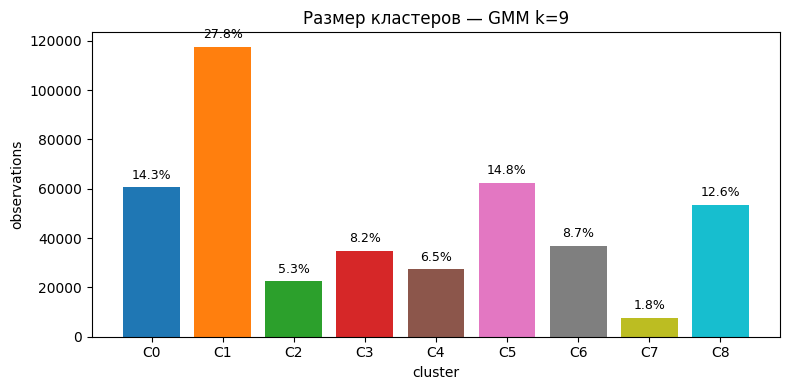

In [49]:
counts = df_viz["cluster"].value_counts().sort_index()
total = len(df_viz)

summary = pd.DataFrame({
    "n_observations": counts,
    "pct": (counts / total * 100).round(2),
})
summary.index.name = "cluster"
display(summary)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(summary.index, summary["n_observations"],
              color=[PALETTE(c) for c in summary.index])
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in summary["pct"]], padding=4, fontsize=9)
ax.set_xlabel("cluster")
ax.set_ylabel("observations")
ax.set_title(f"Размер кластеров — {VIZ_METHOD} k={VIZ_K}")
ax.set_xticks(summary.index)
ax.set_xticklabels([f"C{c}" for c in summary.index])
plt.tight_layout()
plt.show()

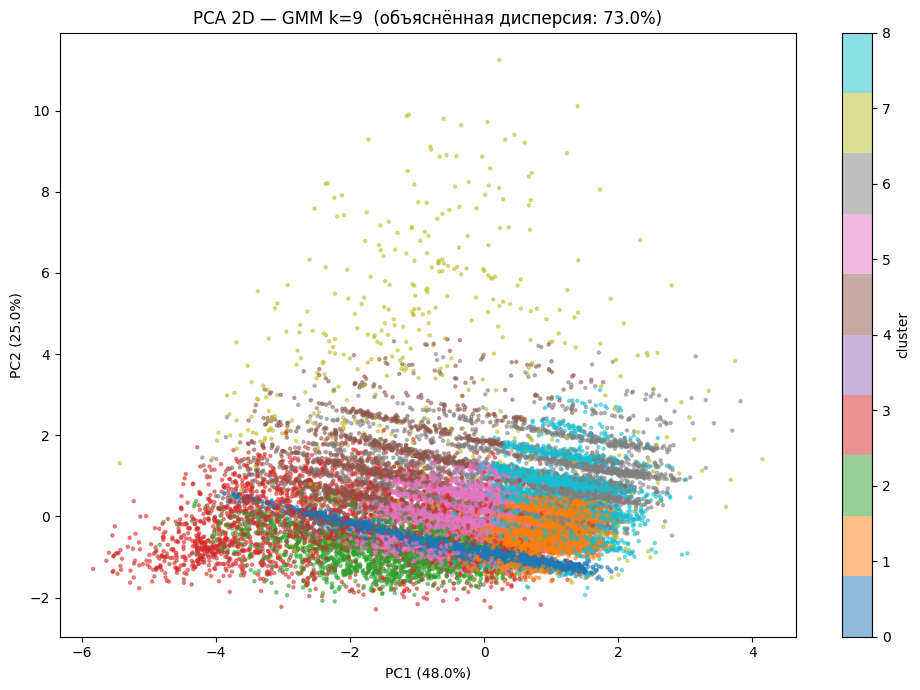

In [50]:
# ── PCA ────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X_s)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(Z_pca[:, 0], Z_pca[:, 1],
                c=df_s["cluster"], cmap="tab10", vmin=0, vmax=VIZ_K - 1,
                s=5, alpha=0.5)
plt.colorbar(sc, ax=ax, label="cluster")
ax.set_title(f"PCA 2D — {VIZ_METHOD} k={VIZ_K}  "
             f"(объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.1%})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.show()

t-SNE на 10,000 точках...


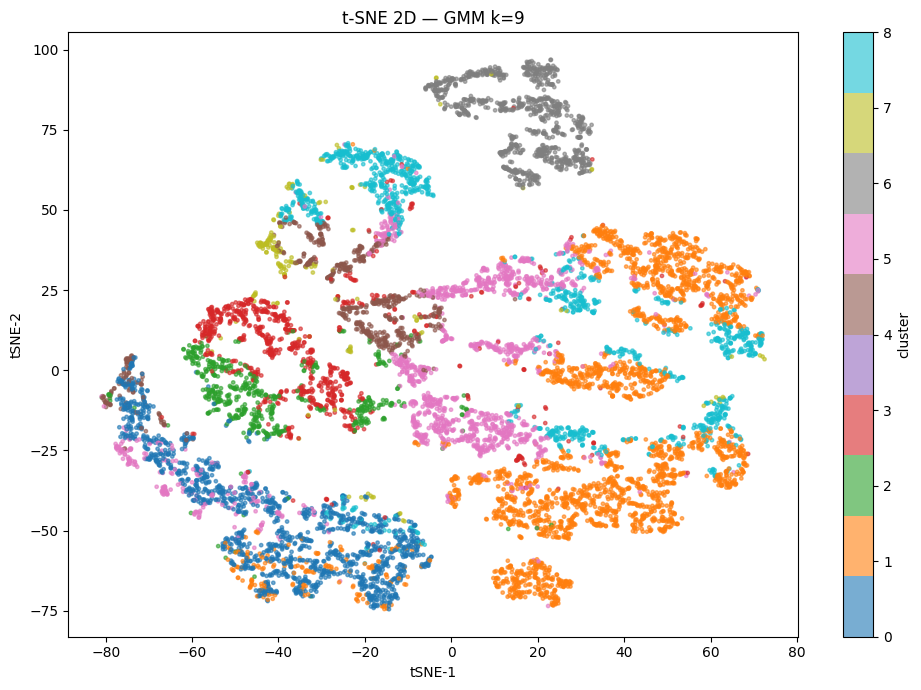

In [51]:
# ── t-SNE ───────────────────────────────────────────────────────────────────
# t-SNE медленный — берём 10k точек
from sklearn.manifold import TSNE

TSNE_N = 10_000
idx_tsne = rng.choice(len(df_s), size=min(TSNE_N, len(df_s)), replace=False)
X_tsne_in = X_s[idx_tsne]
labels_tsne = df_s["cluster"].iloc[idx_tsne].values

print(f"t-SNE на {len(idx_tsne):,} точках...")
Z_tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1).fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                c=labels_tsne, cmap="tab10", vmin=0, vmax=VIZ_K - 1,
                s=6, alpha=0.6)
plt.colorbar(sc, ax=ax, label="cluster")
ax.set_title(f"t-SNE 2D — {VIZ_METHOD} k={VIZ_K}")
ax.set_xlabel("tSNE-1")
ax.set_ylabel("tSNE-2")
plt.tight_layout()
plt.show()

UMAP на 30,000 точках...


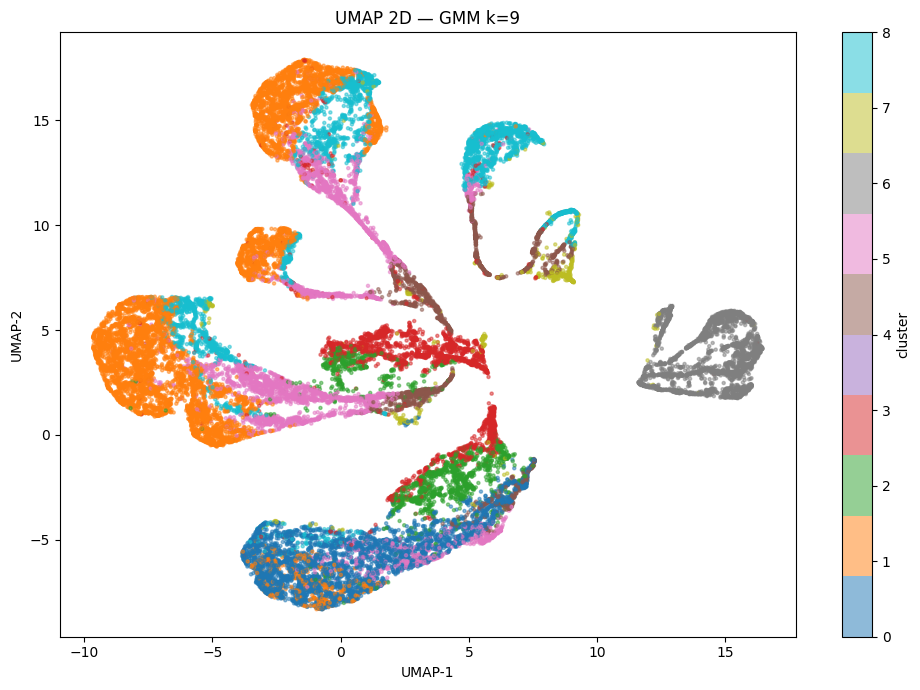

In [52]:
# ── UMAP ────────────────────────────────────────────────────────────────────
import umap

print(f"UMAP на {len(X_s):,} точках...")
Z_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                   random_state=42).fit_transform(X_s)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(Z_umap[:, 0], Z_umap[:, 1],
                c=df_s["cluster"], cmap="tab10", vmin=0, vmax=VIZ_K - 1,
                s=5, alpha=0.5)
plt.colorbar(sc, ax=ax, label="cluster")
ax.set_title(f"UMAP 2D — {VIZ_METHOD} k={VIZ_K}")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.tight_layout()
plt.show()

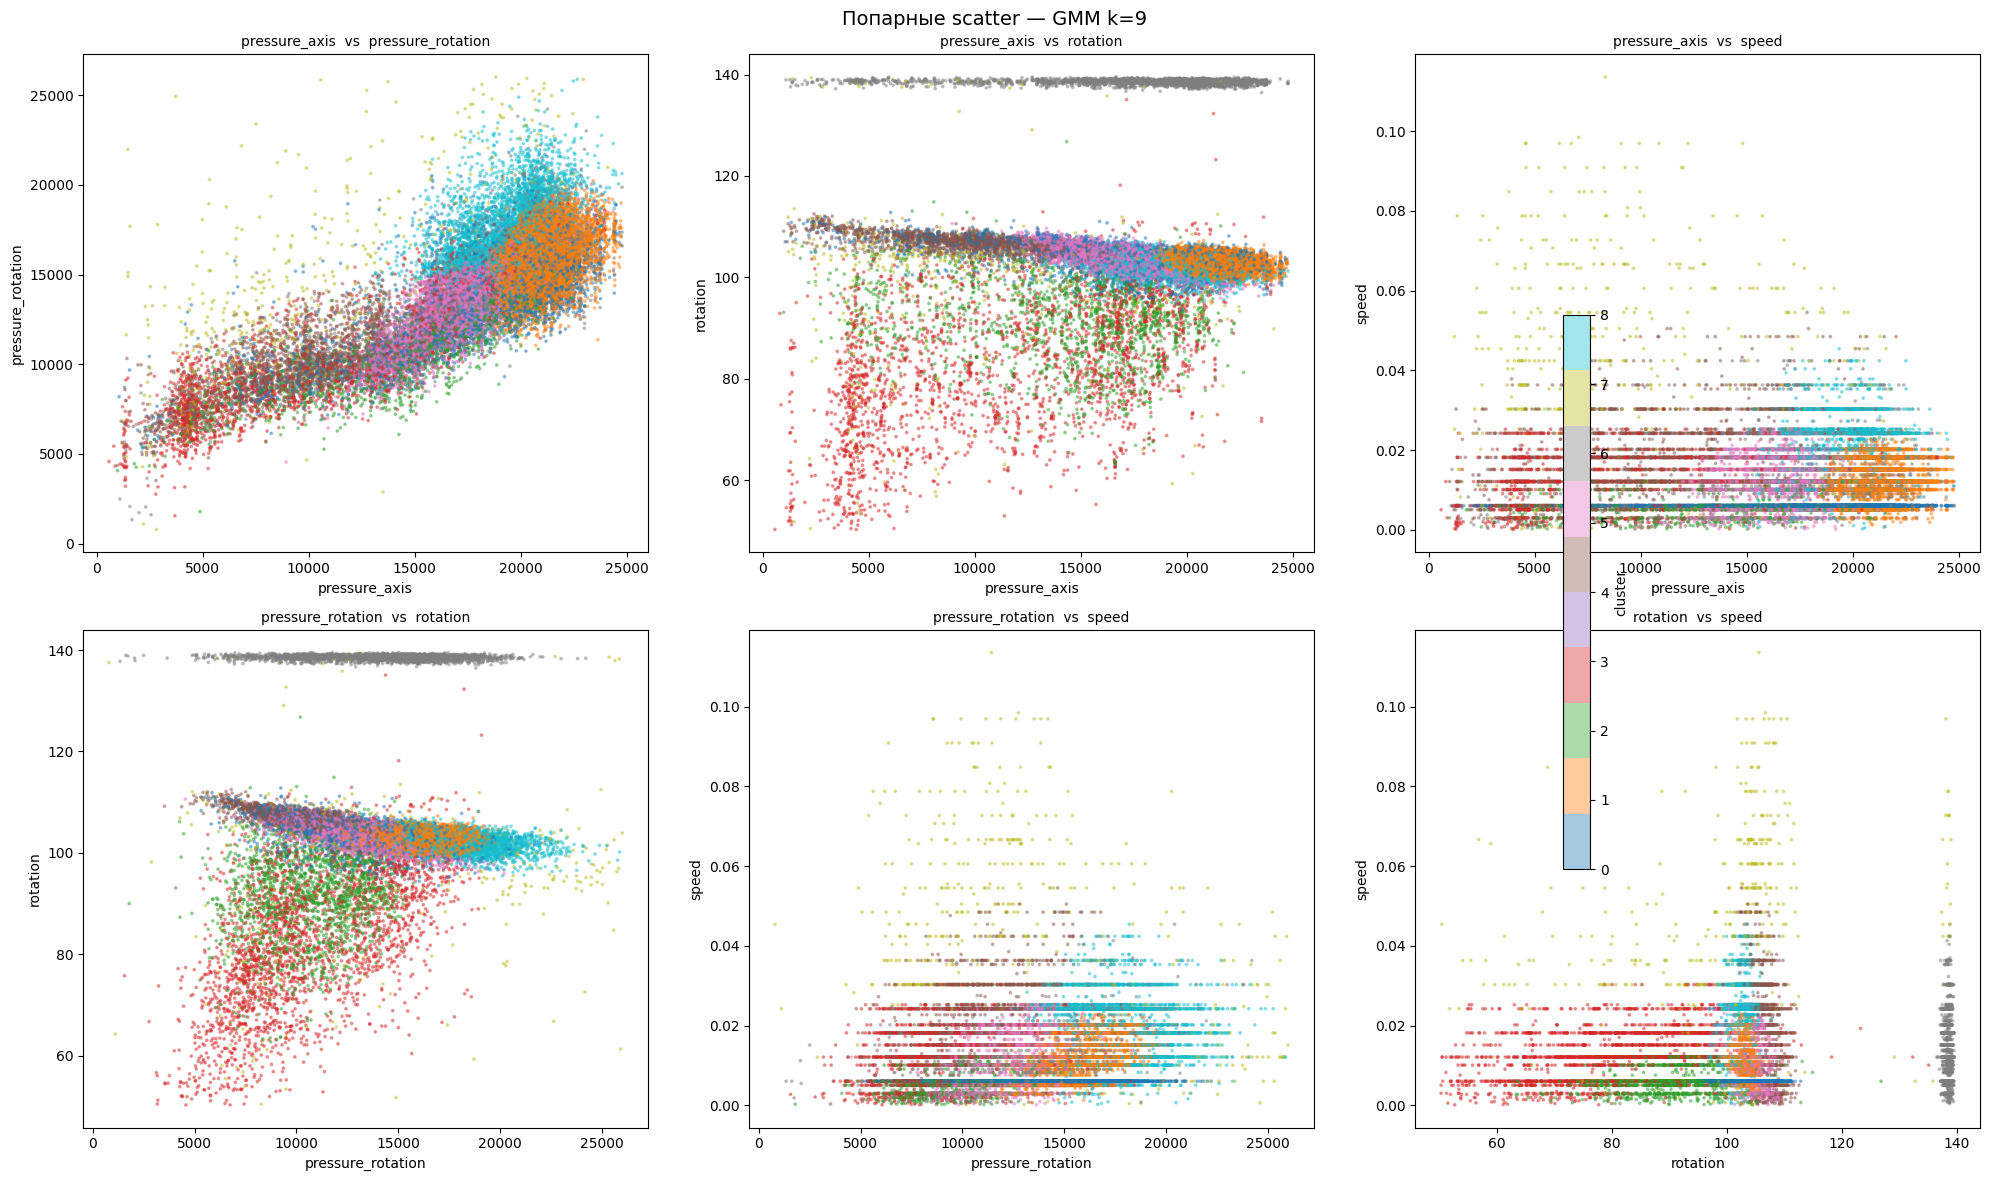

In [ ]:
# ── Pairplot — 2×3 (6 уникальных пар признаков) ────────────────────────────
from itertools import combinations

pairs = list(combinations(CLUSTER_FEATURES, 2))  # 6 пар
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f"Попарные scatter — {VIZ_METHOD} k={VIZ_K}", fontsize=14)

for ax, (fx, fy) in zip(axes.flat, pairs):
    sc = ax.scatter(df_s[fx], df_s[fy],
                    c=df_s["cluster"], cmap="tab10", vmin=0, vmax=VIZ_K - 1,
                    s=3, alpha=0.4)
    ax.set_xlabel(fx, fontsize=10)
    ax.set_ylabel(fy, fontsize=10)
    ax.set_title(f"{fx}  vs  {fy}", fontsize=10)

plt.tight_layout()
plt.show()

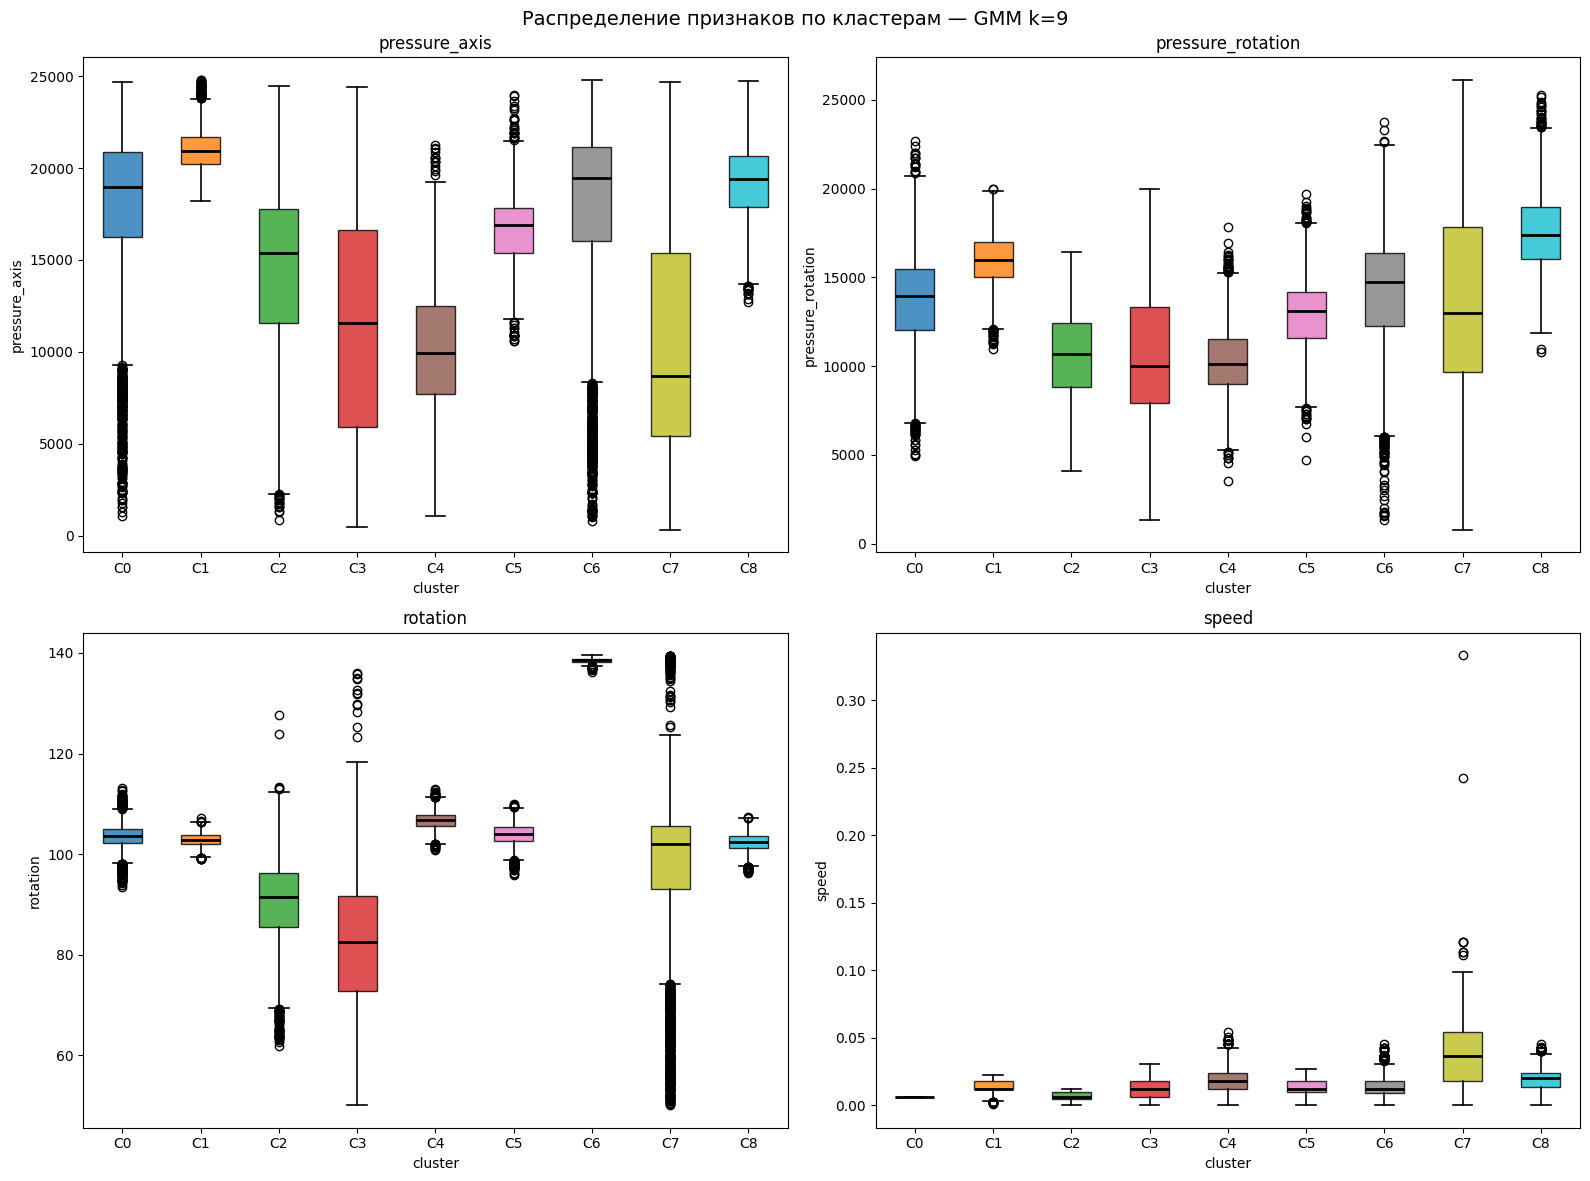

In [54]:
# ── Boxplots — 2×2 (по одному графику на признак) ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Распределение признаков по кластерам — {VIZ_METHOD} k={VIZ_K}", fontsize=14)

for ax, feat in zip(axes.flat, CLUSTER_FEATURES):
    data_by_cluster = [
        df_viz.loc[df_viz["cluster"] == c, feat].sample(
            min(5000, int((df_viz["cluster"] == c).sum())), random_state=42
        )
        for c in range(VIZ_K)
    ]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    for patch, c in zip(bp["boxes"], range(VIZ_K)):
        patch.set_facecolor(PALETTE(c))
        patch.set_alpha(0.8)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("cluster", fontsize=10)
    ax.set_ylabel(feat, fontsize=10)
    ax.set_xticklabels([f"C{c}" for c in range(VIZ_K)])

plt.tight_layout()
plt.show()